# S16_Interpretability_Contradictions_and_Typology

## Introduction

This notebook extends the unified interpretability framework developed in S15 by focusing on contradictions between attribution magnitude, functional impact, and composite reliability. The aim is to identify features whose apparent importance is not matched by ablation-derived model dependence, as well as features with modest attribution magnitude but substantial functional impact.

The notebook uses the S15 outputs as its primary input and generates:
1. contradiction scores quantifying disagreement between importance and functional impact,
2. refined contradiction typology across variants,
3. variant-specific contradiction summaries,
4. publication-ready figures for the third manuscript.

The central question addressed here is whether highly ranked or highly attributed features are also the most reliable and functionally consequential features.

## Imports and paths

In [1]:


from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

INPUT_DIR = Path(".")
OUT_DIR = INPUT_DIR / "S16_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "variants": ["FULL", "CLINICAL", "BIOMARKERS"],
    "eps": 1e-12,
    "high_threshold": 0.67,
    "low_threshold": 0.50,
    "top_k": 5,
    "exclude_unresolved_from_contradiction_core": True,
}

VARIANTS = CONFIG["variants"]
EPS = CONFIG["eps"]
HIGH_THR = CONFIG["high_threshold"]
LOW_THR = CONFIG["low_threshold"]
TOP_K = CONFIG["top_k"]

with open(OUT_DIR / "S16_config_snapshot.json", "w") as f:
    json.dump(CONFIG, f, indent=2)

## Input files

In [7]:
FILE_MAP = {
    "feature_table": INPUT_DIR / "S15_feature_reliability_table.csv",
    "publication_subset": INPUT_DIR / "S15_publication_subset.csv",
    "publication_subset_maintext": INPUT_DIR / "S15_publication_subset_maintext.csv",
    "complete_case_subset": INPUT_DIR / "S15_complete_case_subset.csv",
    "coverage_summary": INPUT_DIR / "S15_coverage_summary.csv",
    "top_features": INPUT_DIR / "S15_top_features_by_variant.csv",
    "variant_summary": INPUT_DIR / "S15_variant_summary.csv",
    "variant_correlation": INPUT_DIR / "S15_variant_correlation_table.csv",
    "winner_diagnostics": INPUT_DIR / "S15_winner_model_diagnostics.csv",
}

for key, path in FILE_MAP.items():
    print(f"{key:>28}: {path.name} | exists={path.exists()}")

               feature_table: S15_feature_reliability_table.csv | exists=True
          publication_subset: S15_publication_subset.csv | exists=True
 publication_subset_maintext: S15_publication_subset_maintext.csv | exists=True
        complete_case_subset: S15_complete_case_subset.csv | exists=True
            coverage_summary: S15_coverage_summary.csv | exists=True
                top_features: S15_top_features_by_variant.csv | exists=True
             variant_summary: S15_variant_summary.csv | exists=False
         variant_correlation: S15_variant_correlation_table.csv | exists=True
          winner_diagnostics: S15_winner_model_diagnostics.csv | exists=True


## Helper functions

In [4]:
def load_csv(path):
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def safe_numeric(series):
    return pd.to_numeric(series, errors="coerce")


def minmax01(series, constant_value=0.0):
    s = pd.Series(series, dtype=float)
    if s.notna().sum() == 0:
        return pd.Series(np.nan, index=s.index)
    s_min = s.min(skipna=True)
    s_max = s.max(skipna=True)
    if pd.isna(s_min) or pd.isna(s_max) or np.isclose(s_max - s_min, 0.0):
        return pd.Series(constant_value, index=s.index, dtype=float)
    return (s - s_min) / (s_max - s_min)


def shorten_label(text, max_len=24):
    text = str(text)
    return text if len(text) <= max_len else text[:max_len - 3] + "..."


def annotate_top_points(ax, data, x_col, y_col, label_col, n=5, fontsize=8):
    sub = data.dropna(subset=[x_col, y_col]).copy()
    if sub.empty:
        return

    x_span = max(sub[x_col].max() - sub[x_col].min(), EPS)
    y_span = max(sub[y_col].max() - sub[y_col].min(), EPS)

    offsets = [
        (0.010 * x_span, 0.020 * y_span),
        (0.010 * x_span, -0.035 * y_span),
        (-0.020 * x_span, 0.020 * y_span),
        (-0.020 * x_span, -0.035 * y_span),
        (0.018 * x_span, 0.040 * y_span),
    ]

    for i, (_, row) in enumerate(sub.head(n).iterrows()):
        dx, dy = offsets[i % len(offsets)]
        ax.annotate(
            shorten_label(row[label_col], max_len=24),
            xy=(row[x_col], row[y_col]),
            xytext=(row[x_col] + dx, row[y_col] + dy),
            textcoords="data",
            fontsize=fontsize,
            ha="left",
            va="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.75),
            arrowprops=dict(arrowstyle="-", lw=0.6, alpha=0.5)
        )


def is_complete_case(row):
    required = ["importance_score", "ablation_score", "stability_score", "FRS"]
    return not any(pd.isna(row.get(col)) for col in required)

## Load S15 outputs

In [10]:
feature_table = load_csv(FILE_MAP["feature_table"])
publication_subset = load_csv(FILE_MAP["publication_subset"])
publication_subset_maintext = load_csv(FILE_MAP["publication_subset_maintext"])
complete_case_subset = load_csv(FILE_MAP["complete_case_subset"])
coverage_summary = load_csv(FILE_MAP["coverage_summary"])
top_features = load_csv(FILE_MAP["top_features"])
variant_summary = load_csv(FILE_MAP["variant_summary"])
variant_correlation = load_csv(FILE_MAP["variant_correlation"])
winner_diagnostics = load_csv(FILE_MAP["winner_diagnostics"])

feature_table.head(10)

,variant,winner_model,feature,importance_mean_raw,importance_mean_nonneg,importance_rank,ablation_delta_auc_mean_raw,ablation_delta_auc_oof_raw,ablation_delta_auc_mean,ablation_delta_auc_oof,importance_score,rank_score,ablation_score,joint_topk_score,cross_variant_consistency,stability_score,functional_consistency_score,winner_diag_signal_score,winner_diag_effect_score,winner_model_reliability_score,FRS_raw,FRS,FRS_rank,interpretability_gap,feature_class
0,BIOMARKERS,RF_SHALLOW,72_kda_pro_mmp_2,0.285683,0.285683,1.0,0.137619,0.148750,0.137619,0.148750,1.000000,1.000000,0.000000,0.0,0.607730,0.803865,0.000000,1.0,0.549557,0.774779,0.601288,1.000000,1.0,1.000000,SPURIOUS_IMPORTANCE
1,BIOMARKERS,RF_SHALLOW,hdl,0.021032,0.021032,5.0,0.474762,0.378125,0.474762,0.378125,0.073619,0.555556,0.758842,1.0,0.975067,0.765311,0.879421,1.0,0.549557,0.774779,0.572784,0.936306,2.0,-0.805802,HIDDEN_SIGNAL
2,BIOMARKERS,RF_SHALLOW,wyniki_fgf23_pg_ml,0.048952,0.048952,3.0,0.340476,0.298125,0.340476,0.298125,0.171352,0.777778,0.456592,0.0,0.959027,0.868402,0.228296,1.0,0.549557,0.774779,0.422684,0.600903,3.0,-0.056943,LOW_SIGNAL
3,BIOMARKERS,RF_SHALLOW,emmprin,0.058841,0.058841,2.0,0.245238,0.247500,0.245238,0.247500,0.205967,0.888889,0.242229,0.0,0.958375,0.923632,0.121115,1.0,0.549557,0.774779,0.416905,0.587990,4.0,0.084853,LOW_SIGNAL
4,BIOMARKERS,RF_SHALLOW,tnfalfa_pg_ml,0.029333,0.029333,4.0,0.403810,0.355000,0.403810,0.355000,0.102678,0.666667,0.599143,0.0,0.965755,0.816211,0.299571,1.0,0.549557,0.774779,0.406153,0.563966,5.0,-0.196893,LOW_SIGNAL
5,BIOMARKERS,RF_SHALLOW,non_hdl_calkowity_hdl,-0.002476,0.000000,8.0,0.581905,0.535625,0.581905,0.535625,0.000000,0.222222,1.000000,0.0,0.922596,0.572409,0.500000,1.0,0.549557,0.774779,0.357470,0.455181,6.0,-0.500000,HIDDEN_SIGNAL
6,BIOMARKERS,RF_SHALLOW,ldl,0.001444,0.001444,6.0,0.464762,0.406875,0.464762,0.406875,0.005056,0.444444,0.736334,0.0,0.926200,0.685322,0.368167,1.0,0.549557,0.774779,0.352848,0.444855,7.0,-0.363111,HIDDEN_SIGNAL
7,BIOMARKERS,RF_SHALLOW,wyniki_klotho_pg_ml,-0.005190,0.000000,9.0,0.556667,0.496875,0.556667,0.496875,0.000000,0.111111,0.943194,0.0,0.922596,0.516853,0.471597,1.0,0.549557,0.774779,0.329483,0.392645,8.0,-0.471597,HIDDEN_SIGNAL
8,BIOMARKERS,RF_SHALLOW,il_6_pg_ml,0.000825,0.000825,7.0,0.429048,0.429375,0.429048,0.429375,0.002889,0.333333,0.655949,0.0,0.924655,0.628994,0.327974,1.0,0.549557,0.774779,0.319953,0.371348,9.0,-0.325085,LOW_SIGNAL
9,BIOMARKERS,RF_SHALLOW,cholesterol_calkowity_tc,-0.005921,0.000000,10.0,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,0.0,0.922596,0.461298,0.000000,1.0,0.549557,0.774779,0.153766,0.000000,10.0,0.000000,UNRESOLVED


## Sanitize columns and restore categoricals


In [11]:
numeric_cols = [
    "importance_mean_raw",
    "importance_mean_nonneg",
    "importance_rank",
    "ablation_delta_auc_mean_raw",
    "ablation_delta_auc_oof_raw",
    "ablation_delta_auc_mean",
    "ablation_delta_auc_oof",
    "importance_score",
    "rank_score",
    "ablation_score",
    "joint_topk_score",
    "cross_variant_consistency",
    "stability_score",
    "functional_consistency_score",
    "winner_diag_signal_score",
    "winner_diag_effect_score",
    "winner_model_reliability_score",
    "FRS_raw",
    "FRS",
    "FRS_rank",
    "interpretability_gap",
]

for col in numeric_cols:
    if col in feature_table.columns:
        feature_table[col] = safe_numeric(feature_table[col])

feature_table["feature_class"] = pd.Categorical(
    feature_table["feature_class"],
    categories=["TRUE_SIGNAL", "SPURIOUS_IMPORTANCE", "HIDDEN_SIGNAL", "LOW_SIGNAL", "UNRESOLVED"],
    ordered=True
)

feature_table["complete_case_flag"] = feature_table.apply(is_complete_case, axis=1).astype(int)

feature_table.head(10)

,variant,winner_model,feature,importance_mean_raw,importance_mean_nonneg,importance_rank,ablation_delta_auc_mean_raw,ablation_delta_auc_oof_raw,ablation_delta_auc_mean,ablation_delta_auc_oof,importance_score,rank_score,ablation_score,joint_topk_score,cross_variant_consistency,stability_score,functional_consistency_score,winner_diag_signal_score,winner_diag_effect_score,winner_model_reliability_score,FRS_raw,FRS,FRS_rank,interpretability_gap,feature_class,complete_case_flag
0,BIOMARKERS,RF_SHALLOW,72_kda_pro_mmp_2,0.285683,0.285683,1.0,0.137619,0.148750,0.137619,0.148750,1.000000,1.000000,0.000000,0.0,0.607730,0.803865,0.000000,1.0,0.549557,0.774779,0.601288,1.000000,1.0,1.000000,SPURIOUS_IMPORTANCE,1
1,BIOMARKERS,RF_SHALLOW,hdl,0.021032,0.021032,5.0,0.474762,0.378125,0.474762,0.378125,0.073619,0.555556,0.758842,1.0,0.975067,0.765311,0.879421,1.0,0.549557,0.774779,0.572784,0.936306,2.0,-0.805802,HIDDEN_SIGNAL,1
2,BIOMARKERS,RF_SHALLOW,wyniki_fgf23_pg_ml,0.048952,0.048952,3.0,0.340476,0.298125,0.340476,0.298125,0.171352,0.777778,0.456592,0.0,0.959027,0.868402,0.228296,1.0,0.549557,0.774779,0.422684,0.600903,3.0,-0.056943,LOW_SIGNAL,1
3,BIOMARKERS,RF_SHALLOW,emmprin,0.058841,0.058841,2.0,0.245238,0.247500,0.245238,0.247500,0.205967,0.888889,0.242229,0.0,0.958375,0.923632,0.121115,1.0,0.549557,0.774779,0.416905,0.587990,4.0,0.084853,LOW_SIGNAL,1
4,BIOMARKERS,RF_SHALLOW,tnfalfa_pg_ml,0.029333,0.029333,4.0,0.403810,0.355000,0.403810,0.355000,0.102678,0.666667,0.599143,0.0,0.965755,0.816211,0.299571,1.0,0.549557,0.774779,0.406153,0.563966,5.0,-0.196893,LOW_SIGNAL,1
5,BIOMARKERS,RF_SHALLOW,non_hdl_calkowity_hdl,-0.002476,0.000000,8.0,0.581905,0.535625,0.581905,0.535625,0.000000,0.222222,1.000000,0.0,0.922596,0.572409,0.500000,1.0,0.549557,0.774779,0.357470,0.455181,6.0,-0.500000,HIDDEN_SIGNAL,1
6,BIOMARKERS,RF_SHALLOW,ldl,0.001444,0.001444,6.0,0.464762,0.406875,0.464762,0.406875,0.005056,0.444444,0.736334,0.0,0.926200,0.685322,0.368167,1.0,0.549557,0.774779,0.352848,0.444855,7.0,-0.363111,HIDDEN_SIGNAL,1
7,BIOMARKERS,RF_SHALLOW,wyniki_klotho_pg_ml,-0.005190,0.000000,9.0,0.556667,0.496875,0.556667,0.496875,0.000000,0.111111,0.943194,0.0,0.922596,0.516853,0.471597,1.0,0.549557,0.774779,0.329483,0.392645,8.0,-0.471597,HIDDEN_SIGNAL,1
8,BIOMARKERS,RF_SHALLOW,il_6_pg_ml,0.000825,0.000825,7.0,0.429048,0.429375,0.429048,0.429375,0.002889,0.333333,0.655949,0.0,0.924655,0.628994,0.327974,1.0,0.549557,0.774779,0.319953,0.371348,9.0,-0.325085,LOW_SIGNAL,1
9,BIOMARKERS,RF_SHALLOW,cholesterol_calkowity_tc,-0.005921,0.000000,10.0,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,0.0,0.922596,0.461298,0.000000,1.0,0.549557,0.774779,0.153766,0.000000,10.0,0.000000,UNRESOLVED,0


## Separate core contradiction table from unresolved coverage

In [12]:
feature_table["unresolved_flag"] = (feature_table["feature_class"] == "UNRESOLVED").astype(int)

contradiction_core = feature_table[feature_table["complete_case_flag"] == 1].copy()
unresolved_only = feature_table[feature_table["complete_case_flag"] == 0].copy()

print("All features:", feature_table.shape[0])
print("Complete-case features:", contradiction_core.shape[0])
print("Unresolved / incomplete features:", unresolved_only.shape[0])

All features: 107
Complete-case features: 49
Unresolved / incomplete features: 58


## Contradiction metrics

In [13]:
contradiction_core["importance_minus_ablation"] = (
    contradiction_core["importance_score"] - contradiction_core["ablation_score"]
)

contradiction_core["ablation_minus_importance"] = (
    contradiction_core["ablation_score"] - contradiction_core["importance_score"]
)

contradiction_core["importance_to_frs_gap"] = (
    contradiction_core["importance_score"] - contradiction_core["FRS"]
)

contradiction_core["frs_to_importance_gap"] = (
    contradiction_core["FRS"] - contradiction_core["importance_score"]
)

contradiction_core["stability_minus_importance"] = (
    contradiction_core["stability_score"] - contradiction_core["importance_score"]
)

contradiction_core["contradiction_abs"] = (
    contradiction_core["importance_score"] - contradiction_core["ablation_score"]
).abs()

contradiction_core["contradiction_signed"] = (
    contradiction_core["importance_score"] - contradiction_core["ablation_score"]
)

contradiction_core["contradiction_score"] = (
    contradiction_core.groupby("variant")["contradiction_abs"]
    .transform(lambda s: minmax01(s, constant_value=0.0))
)

contradiction_core["importance_excess_flag"] = (
    (contradiction_core["importance_score"] >= HIGH_THR) &
    (contradiction_core["ablation_score"] < LOW_THR)
).astype(int)

contradiction_core["hidden_impact_flag"] = (
    (contradiction_core["importance_score"] < LOW_THR) &
    (contradiction_core["ablation_score"] >= HIGH_THR)
).astype(int)

contradiction_core["reliable_high_impact_flag"] = (
    (contradiction_core["FRS"] >= HIGH_THR) &
    (contradiction_core["ablation_score"] >= HIGH_THR)
).astype(int)

contradiction_core.head(10)

,variant,winner_model,feature,importance_mean_raw,importance_mean_nonneg,importance_rank,ablation_delta_auc_mean_raw,ablation_delta_auc_oof_raw,ablation_delta_auc_mean,ablation_delta_auc_oof,importance_score,rank_score,ablation_score,joint_topk_score,cross_variant_consistency,stability_score,functional_consistency_score,winner_diag_signal_score,winner_diag_effect_score,winner_model_reliability_score,FRS_raw,FRS,FRS_rank,interpretability_gap,feature_class,complete_case_flag,unresolved_flag,importance_minus_ablation,ablation_minus_importance,importance_to_frs_gap,frs_to_importance_gap,stability_minus_importance,contradiction_abs,contradiction_signed,contradiction_score,importance_excess_flag,hidden_impact_flag,reliable_high_impact_flag
0,BIOMARKERS,RF_SHALLOW,72_kda_pro_mmp_2,0.285683,0.285683,1.0,0.137619,0.148750,0.137619,0.148750,1.000000,1.000000,0.000000,0.0,0.607730,0.803865,0.000000,1.00000,0.549557,0.774779,0.601288,1.000000,1.0,1.000000,SPURIOUS_IMPORTANCE,1,0,1.000000,-1.000000,0.000000,0.000000,-0.196135,1.000000,1.000000,1.000000,1,0,0
1,BIOMARKERS,RF_SHALLOW,hdl,0.021032,0.021032,5.0,0.474762,0.378125,0.474762,0.378125,0.073619,0.555556,0.758842,1.0,0.975067,0.765311,0.879421,1.00000,0.549557,0.774779,0.572784,0.936306,2.0,-0.805802,HIDDEN_SIGNAL,1,0,-0.685223,0.685223,-0.862687,0.862687,0.691692,0.685223,-0.685223,0.673379,0,1,1
2,BIOMARKERS,RF_SHALLOW,wyniki_fgf23_pg_ml,0.048952,0.048952,3.0,0.340476,0.298125,0.340476,0.298125,0.171352,0.777778,0.456592,0.0,0.959027,0.868402,0.228296,1.00000,0.549557,0.774779,0.422684,0.600903,3.0,-0.056943,LOW_SIGNAL,1,0,-0.285239,0.285239,-0.429551,0.429551,0.697050,0.285239,-0.285239,0.258345,0,0,0
3,BIOMARKERS,RF_SHALLOW,emmprin,0.058841,0.058841,2.0,0.245238,0.247500,0.245238,0.247500,0.205967,0.888889,0.242229,0.0,0.958375,0.923632,0.121115,1.00000,0.549557,0.774779,0.416905,0.587990,4.0,0.084853,LOW_SIGNAL,1,0,-0.036262,0.036262,-0.382023,0.382023,0.717664,0.036262,-0.036262,0.000000,0,0,0
4,BIOMARKERS,RF_SHALLOW,tnfalfa_pg_ml,0.029333,0.029333,4.0,0.403810,0.355000,0.403810,0.355000,0.102678,0.666667,0.599143,0.0,0.965755,0.816211,0.299571,1.00000,0.549557,0.774779,0.406153,0.563966,5.0,-0.196893,LOW_SIGNAL,1,0,-0.496464,0.496464,-0.461288,0.461288,0.713533,0.496464,-0.496464,0.477518,0,0,0
5,BIOMARKERS,RF_SHALLOW,non_hdl_calkowity_hdl,-0.002476,0.000000,8.0,0.581905,0.535625,0.581905,0.535625,0.000000,0.222222,1.000000,0.0,0.922596,0.572409,0.500000,1.00000,0.549557,0.774779,0.357470,0.455181,6.0,-0.500000,HIDDEN_SIGNAL,1,0,-1.000000,1.000000,-0.455181,0.455181,0.572409,1.000000,-1.000000,1.000000,0,1,0
6,BIOMARKERS,RF_SHALLOW,ldl,0.001444,0.001444,6.0,0.464762,0.406875,0.464762,0.406875,0.005056,0.444444,0.736334,0.0,0.926200,0.685322,0.368167,1.00000,0.549557,0.774779,0.352848,0.444855,7.0,-0.363111,HIDDEN_SIGNAL,1,0,-0.731278,0.731278,-0.439799,0.439799,0.680266,0.731278,-0.731278,0.721167,0,1,0
7,BIOMARKERS,RF_SHALLOW,wyniki_klotho_pg_ml,-0.005190,0.000000,9.0,0.556667,0.496875,0.556667,0.496875,0.000000,0.111111,0.943194,0.0,0.922596,0.516853,0.471597,1.00000,0.549557,0.774779,0.329483,0.392645,8.0,-0.471597,HIDDEN_SIGNAL,1,0,-0.943194,0.943194,-0.392645,0.392645,0.516853,0.943194,-0.943194,0.941057,0,1,0
8,BIOMARKERS,RF_SHALLOW,il_6_pg_ml,0.000825,0.000825,7.0,0.429048,0.429375,0.429048,0.429375,0.002889,0.333333,0.655949,0.0,0.924655,0.628994,0.327974,1.00000,0.549557,0.774779,0.319953,0.371348,9.0,-0.325085,LOW_SIGNAL,1,0,-0.653059,0.653059,-0.368459,0.368459,0.626105,0.653059,-0.653059,0.640005,0,0,0
10,CLINICAL,RF_SHALLOW,wiek_w_momencie_zbiorki,0.004730,0.004730,1.0,-0.015238,0.052500,0.000000,0.052500,1.000000,1.000000,0.000000,0.0,0.000000,0.500000,0.000000,0.45098,0.113102,0.282041,0.500000,1.000000,1.0,1.000000,SPURIOUS_IMPORTANCE,1,0,1.000000,-1.000000,0.000000,0.000000,-0.500000,1.000000,1.000000,1.000000,1,0,0


## Contradiction class

In [14]:
def classify_contradiction(row):
    if pd.isna(row["importance_score"]) or pd.isna(row["ablation_score"]) or pd.isna(row["FRS"]):
        return "UNRESOLVED"

    high_importance = row["importance_score"] >= HIGH_THR
    high_ablation = row["ablation_score"] >= HIGH_THR
    high_reliability = row["FRS"] >= HIGH_THR
    high_stability = row["stability_score"] >= HIGH_THR

    if high_importance and high_ablation and high_reliability and high_stability:
        return "CONVERGENT_SIGNAL"
    elif high_importance and not high_ablation:
        return "ATTRIBUTION_EXCESS"
    elif (not high_importance) and high_ablation:
        return "LATENT_DEPENDENCE"
    elif high_reliability and (not high_importance) and high_stability:
        return "RELIABLE_NONDOMINANT"
    else:
        return "LOW_EVIDENCE"

contradiction_core["contradiction_class"] = contradiction_core.apply(classify_contradiction, axis=1)

contradiction_core["contradiction_class"] = pd.Categorical(
    contradiction_core["contradiction_class"],
    categories=[
        "CONVERGENT_SIGNAL",
        "ATTRIBUTION_EXCESS",
        "LATENT_DEPENDENCE",
        "RELIABLE_NONDOMINANT",
        "LOW_EVIDENCE",
    ],
    ordered=True
)

# propagate back to the full table
feature_table = feature_table.merge(
    contradiction_core[["variant", "feature", "contradiction_class", "contradiction_abs", "contradiction_signed", "contradiction_score",
                        "importance_excess_flag", "hidden_impact_flag", "reliable_high_impact_flag"]],
    on=["variant", "feature"],
    how="left",
    validate="one_to_one"
)

feature_table["contradiction_class"] = feature_table["contradiction_class"].astype("object")
feature_table.loc[feature_table["complete_case_flag"] == 0, "contradiction_class"] = "UNRESOLVED"

feature_table["contradiction_class"] = pd.Categorical(
    feature_table["contradiction_class"],
    categories=[
        "CONVERGENT_SIGNAL",
        "ATTRIBUTION_EXCESS",
        "LATENT_DEPENDENCE",
        "RELIABLE_NONDOMINANT",
        "LOW_EVIDENCE",
        "UNRESOLVED",
    ],
    ordered=True
)

feature_table[["variant", "feature", "feature_class", "contradiction_class"]].head(15)

,variant,feature,feature_class,contradiction_class
0,BIOMARKERS,72_kda_pro_mmp_2,SPURIOUS_IMPORTANCE,ATTRIBUTION_EXCESS
1,BIOMARKERS,hdl,HIDDEN_SIGNAL,LATENT_DEPENDENCE
2,BIOMARKERS,wyniki_fgf23_pg_ml,LOW_SIGNAL,LOW_EVIDENCE
3,BIOMARKERS,emmprin,LOW_SIGNAL,LOW_EVIDENCE
4,BIOMARKERS,tnfalfa_pg_ml,LOW_SIGNAL,LOW_EVIDENCE
5,BIOMARKERS,non_hdl_calkowity_hdl,HIDDEN_SIGNAL,LATENT_DEPENDENCE
6,BIOMARKERS,ldl,HIDDEN_SIGNAL,LATENT_DEPENDENCE
7,BIOMARKERS,wyniki_klotho_pg_ml,HIDDEN_SIGNAL,LATENT_DEPENDENCE
8,BIOMARKERS,il_6_pg_ml,LOW_SIGNAL,LOW_EVIDENCE
9,BIOMARKERS,cholesterol_calkowity_tc,UNRESOLVED,UNRESOLVED


## Contradiction summary by variant

In [15]:
contradiction_summary = (
    feature_table.groupby("variant")
    .agg(
        n_features=("feature", "nunique"),
        n_complete_case=("complete_case_flag", "sum"),
        n_unresolved=("unresolved_flag", "sum"),
        mean_importance_nonneg=("importance_mean_nonneg", "mean"),
        mean_ablation=("ablation_delta_auc_mean", "mean"),
        mean_frs=("FRS", "mean"),
        mean_contradiction_abs=("contradiction_abs", "mean"),
        median_contradiction_abs=("contradiction_abs", "median"),
        n_importance_excess=("importance_excess_flag", "sum"),
        n_hidden_impact=("hidden_impact_flag", "sum"),
        n_reliable_high_impact=("reliable_high_impact_flag", "sum")
    )
    .reset_index()
    .sort_values("variant")
)

contradiction_summary.to_csv(OUT_DIR / "S16_variant_contradiction_summary.csv", index=False)
contradiction_summary

,variant,n_features,n_complete_case,n_unresolved,mean_importance_nonneg,mean_ablation,mean_frs,mean_contradiction_abs,median_contradiction_abs,n_importance_excess,n_hidden_impact,n_reliable_high_impact
0,BIOMARKERS,10,9,1,0.044611,0.403810,0.535319,0.647858,0.685223,1.0,4.0,1.0
1,CLINICAL,43,20,23,0.000283,0.017714,0.389389,0.384492,0.312500,1.0,4.0,2.0
2,FULL,54,20,34,0.004301,0.306643,0.325798,0.712559,0.744949,1.0,14.0,1.0


## Contradiction class summary

In [16]:
contradiction_class_summary = (
    feature_table.groupby(["variant", "contradiction_class"], observed=False)
    .agg(
        n_features=("feature", "nunique"),
        mean_importance_score=("importance_score", "mean"),
        mean_ablation_score=("ablation_score", "mean"),
        mean_stability_score=("stability_score", "mean"),
        mean_FRS=("FRS", "mean"),
        mean_contradiction=("contradiction_abs", "mean")
    )
    .reset_index()
    .sort_values(["variant", "contradiction_class"])
)

contradiction_class_summary.to_csv(OUT_DIR / "S16_contradiction_class_summary.csv", index=False)
contradiction_class_summary

,variant,contradiction_class,n_features,mean_importance_score,mean_ablation_score,mean_stability_score,mean_FRS,mean_contradiction
0,BIOMARKERS,CONVERGENT_SIGNAL,0,NaN,NaN,NaN,NaN,NaN
1,BIOMARKERS,ATTRIBUTION_EXCESS,1,1.000000,0.000000,0.803865,1.000000,1.000000
2,BIOMARKERS,LATENT_DEPENDENCE,4,0.019669,0.859593,0.634974,0.557247,0.839924
3,BIOMARKERS,RELIABLE_NONDOMINANT,0,NaN,NaN,NaN,NaN,NaN
4,BIOMARKERS,LOW_EVIDENCE,4,0.120722,0.488478,0.809310,0.531052,0.367756
5,BIOMARKERS,UNRESOLVED,1,0.000000,NaN,0.461298,0.000000,NaN
6,CLINICAL,CONVERGENT_SIGNAL,0,NaN,NaN,NaN,NaN,NaN
7,CLINICAL,ATTRIBUTION_EXCESS,1,1.000000,0.000000,0.500000,1.000000,1.000000
8,CLINICAL,LATENT_DEPENDENCE,4,0.000000,0.821429,0.794829,0.709541,0.821429
9,CLINICAL,RELIABLE_NONDOMINANT,2,0.000000,0.580357,0.900298,0.694679,0.580357


## Top contradiction features

In [17]:
top_attr_excess = (
    contradiction_core.sort_values(["variant", "contradiction_signed"], ascending=[True, False])
    .groupby("variant", group_keys=False)
    .head(10)
    .reset_index(drop=True)
)

top_latent_dependence = (
    contradiction_core.sort_values(["variant", "contradiction_signed"], ascending=[True, True])
    .groupby("variant", group_keys=False)
    .head(10)
    .reset_index(drop=True)
)

top_attr_excess.to_csv(OUT_DIR / "S16_top_attribution_excess_features.csv", index=False)
top_latent_dependence.to_csv(OUT_DIR / "S16_top_latent_dependence_features.csv", index=False)

top_attr_excess.head(15)

,variant,winner_model,feature,importance_mean_raw,importance_mean_nonneg,importance_rank,ablation_delta_auc_mean_raw,ablation_delta_auc_oof_raw,ablation_delta_auc_mean,ablation_delta_auc_oof,importance_score,rank_score,ablation_score,joint_topk_score,cross_variant_consistency,stability_score,functional_consistency_score,winner_diag_signal_score,winner_diag_effect_score,winner_model_reliability_score,FRS_raw,FRS,FRS_rank,interpretability_gap,feature_class,complete_case_flag,unresolved_flag,importance_minus_ablation,ablation_minus_importance,importance_to_frs_gap,frs_to_importance_gap,stability_minus_importance,contradiction_abs,contradiction_signed,contradiction_score,importance_excess_flag,hidden_impact_flag,reliable_high_impact_flag,contradiction_class
0,BIOMARKERS,RF_SHALLOW,72_kda_pro_mmp_2,0.285683,0.285683,1.0,0.137619,0.148750,0.137619,0.148750,1.000000,1.000000,0.000000,0.0,0.607730,0.803865,0.000000,1.00000,0.549557,0.774779,0.601288,1.000000,1.0,1.000000,SPURIOUS_IMPORTANCE,1,0,1.000000,-1.000000,0.000000,0.000000,-0.196135,1.000000,1.000000,1.000000,1,0,0,ATTRIBUTION_EXCESS
1,BIOMARKERS,RF_SHALLOW,emmprin,0.058841,0.058841,2.0,0.245238,0.247500,0.245238,0.247500,0.205967,0.888889,0.242229,0.0,0.958375,0.923632,0.121115,1.00000,0.549557,0.774779,0.416905,0.587990,4.0,0.084853,LOW_SIGNAL,1,0,-0.036262,0.036262,-0.382023,0.382023,0.717664,0.036262,-0.036262,0.000000,0,0,0,LOW_EVIDENCE
2,BIOMARKERS,RF_SHALLOW,wyniki_fgf23_pg_ml,0.048952,0.048952,3.0,0.340476,0.298125,0.340476,0.298125,0.171352,0.777778,0.456592,0.0,0.959027,0.868402,0.228296,1.00000,0.549557,0.774779,0.422684,0.600903,3.0,-0.056943,LOW_SIGNAL,1,0,-0.285239,0.285239,-0.429551,0.429551,0.697050,0.285239,-0.285239,0.258345,0,0,0,LOW_EVIDENCE
3,BIOMARKERS,RF_SHALLOW,tnfalfa_pg_ml,0.029333,0.029333,4.0,0.403810,0.355000,0.403810,0.355000,0.102678,0.666667,0.599143,0.0,0.965755,0.816211,0.299571,1.00000,0.549557,0.774779,0.406153,0.563966,5.0,-0.196893,LOW_SIGNAL,1,0,-0.496464,0.496464,-0.461288,0.461288,0.713533,0.496464,-0.496464,0.477518,0,0,0,LOW_EVIDENCE
4,BIOMARKERS,RF_SHALLOW,il_6_pg_ml,0.000825,0.000825,7.0,0.429048,0.429375,0.429048,0.429375,0.002889,0.333333,0.655949,0.0,0.924655,0.628994,0.327974,1.00000,0.549557,0.774779,0.319953,0.371348,9.0,-0.325085,LOW_SIGNAL,1,0,-0.653059,0.653059,-0.368459,0.368459,0.626105,0.653059,-0.653059,0.640005,0,0,0,LOW_EVIDENCE
5,BIOMARKERS,RF_SHALLOW,hdl,0.021032,0.021032,5.0,0.474762,0.378125,0.474762,0.378125,0.073619,0.555556,0.758842,1.0,0.975067,0.765311,0.879421,1.00000,0.549557,0.774779,0.572784,0.936306,2.0,-0.805802,HIDDEN_SIGNAL,1,0,-0.685223,0.685223,-0.862687,0.862687,0.691692,0.685223,-0.685223,0.673379,0,1,1,LATENT_DEPENDENCE
6,BIOMARKERS,RF_SHALLOW,ldl,0.001444,0.001444,6.0,0.464762,0.406875,0.464762,0.406875,0.005056,0.444444,0.736334,0.0,0.926200,0.685322,0.368167,1.00000,0.549557,0.774779,0.352848,0.444855,7.0,-0.363111,HIDDEN_SIGNAL,1,0,-0.731278,0.731278,-0.439799,0.439799,0.680266,0.731278,-0.731278,0.721167,0,1,0,LATENT_DEPENDENCE
7,BIOMARKERS,RF_SHALLOW,wyniki_klotho_pg_ml,-0.005190,0.000000,9.0,0.556667,0.496875,0.556667,0.496875,0.000000,0.111111,0.943194,0.0,0.922596,0.516853,0.471597,1.00000,0.549557,0.774779,0.329483,0.392645,8.0,-0.471597,HIDDEN_SIGNAL,1,0,-0.943194,0.943194,-0.392645,0.392645,0.516853,0.943194,-0.943194,0.941057,0,1,0,LATENT_DEPENDENCE
8,BIOMARKERS,RF_SHALLOW,non_hdl_calkowity_hdl,-0.002476,0.000000,8.0,0.581905,0.535625,0.581905,0.535625,0.000000,0.222222,1.000000,0.0,0.922596,0.572409,0.500000,1.00000,0.549557,0.774779,0.357470,0.455181,6.0,-0.500000,HIDDEN_SIGNAL,1,0,-1.000000,1.000000,-0.455181,0.455181,0.572409,1.000000,-1.000000,1.000000,0,1,0,LATENT_DEPENDENCE
9,CLINICAL,RF_SHALLOW,wiek_w_momencie_zbiorki,0.004730,0.004730,1.0,-0.015238,0.052500,0.000000,0.052500,1.000000,1.000000,0.000000,0.0,0.000000,0.500000,0.000000,0.45098,0.113102,0.282041,0.500000,1.000000,1.0,1.000000,SPURIOUS_IMPORTANCE,1,0,1.000000,-1.000000,0.000000,0.000000,-0.500000,1.000000,1.000000

## Variant profile with correlations

In [18]:
s16_variant_profile = (
    feature_table.groupby("variant")
    .agg(
        mean_contradiction_abs=("contradiction_abs", "mean"),
        mean_contradiction_signed=("contradiction_signed", "mean"),
        mean_importance_score=("importance_score", "mean"),
        mean_ablation_score=("ablation_score", "mean"),
        mean_FRS=("FRS", "mean"),
        n_complete_case=("complete_case_flag", "sum"),
        n_unresolved=("unresolved_flag", "sum")
    )
    .reset_index()
)

s16_variant_profile = s16_variant_profile.merge(
    variant_correlation,
    on="variant",
    how="left",
    validate="one_to_one"
).sort_values("variant").reset_index(drop=True)

s16_variant_profile.to_csv(OUT_DIR / "S16_variant_profile_with_correlations.csv", index=False)
s16_variant_profile

,variant,mean_contradiction_abs,mean_contradiction_signed,mean_importance_score,mean_ablation_score,mean_FRS,n_complete_case,n_unresolved,n_features,corr_importance_vs_ablation_spearman,corr_importance_vs_FRS_spearman,corr_ablation_vs_FRS_spearman,topk_overlap_importance_ablation,mean_absolute_gap,median_absolute_gap
0,BIOMARKERS,0.647858,-0.425636,0.156156,0.599143,0.535319,9,1,10,-0.928878,0.816012,-0.533333,1,0.647858,0.685223
1,CLINICAL,0.384492,-0.279794,0.059778,0.332143,0.389389,20,23,43,-0.383385,0.453170,0.619990,0,0.384492,0.312500
2,FULL,0.712559,-0.612559,0.022271,0.671654,0.325798,20,34,54,-0.373526,0.530453,0.258647,1,0.712559,0.744949


## Publication table

In [19]:
s16_publication_table = feature_table[[
    "variant",
    "winner_model",
    "feature",
    "importance_mean_nonneg",
    "ablation_delta_auc_mean",
    "importance_score",
    "ablation_score",
    "stability_score",
    "FRS",
    "contradiction_abs",
    "contradiction_signed",
    "feature_class",
    "contradiction_class",
    "complete_case_flag"
]].sort_values(["variant", "contradiction_abs"], ascending=[True, False]).reset_index(drop=True)

s16_publication_table.to_csv(OUT_DIR / "S16_publication_table.csv", index=False)
s16_publication_table.head(20)

,variant,winner_model,feature,importance_mean_nonneg,ablation_delta_auc_mean,importance_score,ablation_score,stability_score,FRS,contradiction_abs,contradiction_signed,feature_class,contradiction_class,complete_case_flag
0,BIOMARKERS,RF_SHALLOW,72_kda_pro_mmp_2,0.285683,0.137619,1.000000,0.000000,0.803865,1.000000,1.000000,1.000000,SPURIOUS_IMPORTANCE,ATTRIBUTION_EXCESS,1
1,BIOMARKERS,RF_SHALLOW,non_hdl_calkowity_hdl,0.000000,0.581905,0.000000,1.000000,0.572409,0.455181,1.000000,-1.000000,HIDDEN_SIGNAL,LATENT_DEPENDENCE,1
2,BIOMARKERS,RF_SHALLOW,wyniki_klotho_pg_ml,0.000000,0.556667,0.000000,0.943194,0.516853,0.392645,0.943194,-0.943194,HIDDEN_SIGNAL,LATENT_DEPENDENCE,1
3,BIOMARKERS,RF_SHALLOW,ldl,0.001444,0.464762,0.005056,0.736334,0.685322,0.444855,0.731278,-0.731278,HIDDEN_SIGNAL,LATENT_DEPENDENCE,1
4,BIOMARKERS,RF_SHALLOW,hdl,0.021032,0.474762,0.073619,0.758842,0.765311,0.936306,0.685223,-0.685223,HIDDEN_SIGNAL,LATENT_DEPENDENCE,1
5,BIOMARKERS,RF_SHALLOW,il_6_pg_ml,0.000825,0.429048,0.002889,0.655949,0.628994,0.371348,0.653059,-0.653059,LOW_SIGNAL,LOW_EVIDENCE,1
6,BIOMARKERS,RF_SHALLOW,tnfalfa_pg_ml,0.029333,0.403810,0.102678,0.599143,0.816211,0.563966,0.496464,-0.496464,LOW_SIGNAL,LOW_EVIDENCE,1
7,BIOMARKERS,RF_SHALLOW,wyniki_fgf23_pg_ml,0.048952,0.340476,0.171352,0.456592,0.868402,0.600903,0.285239,-0.285239,LOW_SIGNAL,LOW_EVIDENCE,1
8,BIOMARKERS,RF_SHALLOW,emmprin,0.058841,0.245238,0.205967,0.242229,0.923632,0.587990,0.036262,-0.036262,LOW_SIGNAL,LOW_EVIDENCE,1
9,BIOMARKERS,RF_SHALLOW,cholesterol_calkowity_tc,0.000000,NaN,0.000000,NaN,0.461298,0.000000,NaN,NaN,UNRESOLVED,UNRESOLVED,0


## Plot styles

In [20]:
class_order = [
    "CONVERGENT_SIGNAL",
    "ATTRIBUTION_EXCESS",
    "LATENT_DEPENDENCE",
    "RELIABLE_NONDOMINANT",
    "LOW_EVIDENCE",
    "UNRESOLVED",
]

marker_map = {
    "CONVERGENT_SIGNAL": "o",
    "ATTRIBUTION_EXCESS": "s",
    "LATENT_DEPENDENCE": "^",
    "RELIABLE_NONDOMINANT": "D",
    "LOW_EVIDENCE": "x",
    "UNRESOLVED": "P",
}

class_colors = {
    "CONVERGENT_SIGNAL": "#2ca02c",
    "ATTRIBUTION_EXCESS": "#d62728",
    "LATENT_DEPENDENCE": "#1f77b4",
    "RELIABLE_NONDOMINANT": "#9467bd",
    "LOW_EVIDENCE": "#7f7f7f",
    "UNRESOLVED": "#cccccc",
}

## Plot 1: importance vs ablation by contradiction class

/tmp/ipykernel_22686/1320384324.py:12: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
/tmp/ipykernel_22686/1320384324.py:12: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
/tmp/ipykernel_22686/1320384324.py:12: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


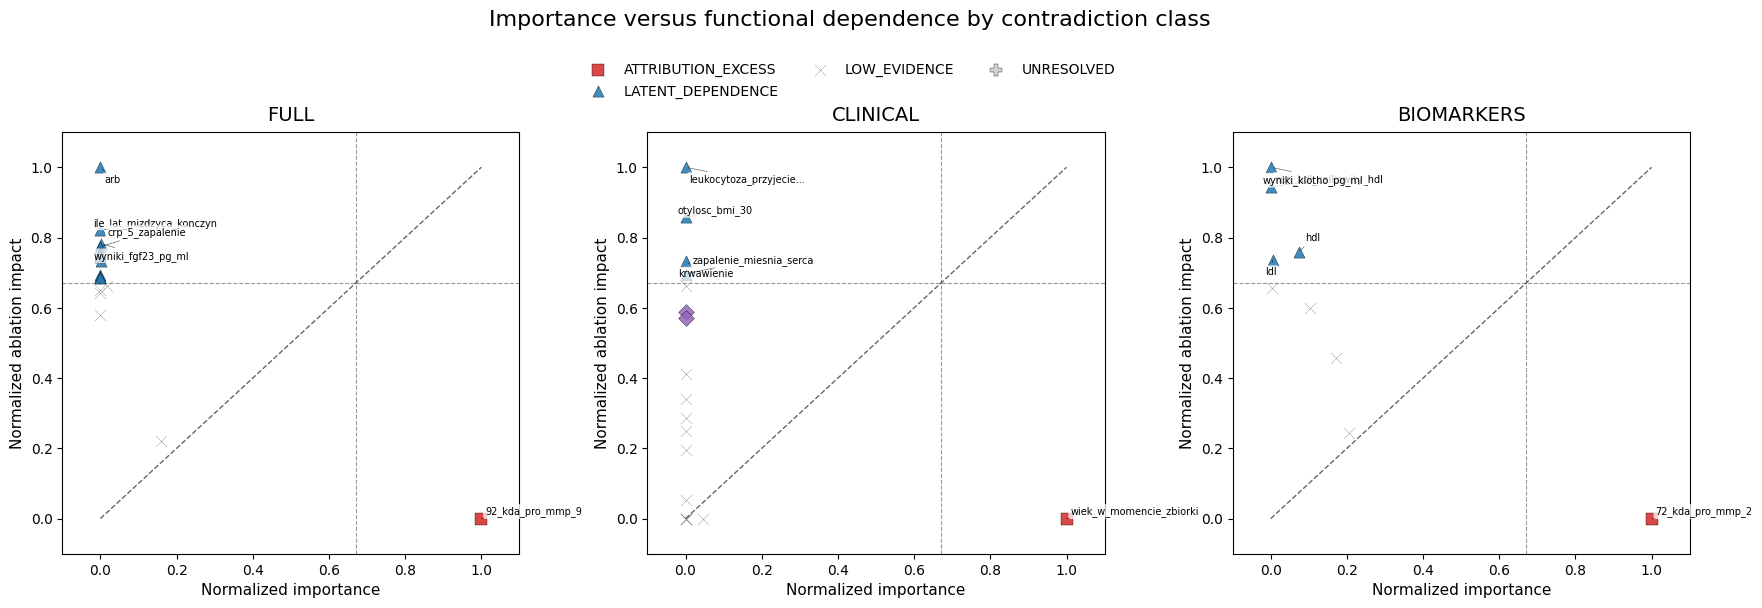

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6.8))
fig.subplots_adjust(top=0.80, bottom=0.18, wspace=0.28)

for ax, variant in zip(axes, VARIANTS):
    sub = feature_table.query("variant == @variant").copy()

    for cls in class_order:
        part = sub[sub["contradiction_class"] == cls]
        if part.empty:
            continue

        ax.scatter(
            part["importance_score"],
            part["ablation_score"],
            s=65,
            marker=marker_map[cls],
            alpha=0.85,
            label=cls,
            color=class_colors[cls],
            edgecolor="black",
            linewidth=0.3
        )

    annotate_top_points(
        ax=ax,
        data=sub.query("contradiction_class != 'UNRESOLVED'").sort_values("contradiction_abs", ascending=False),
        x_col="importance_score",
        y_col="ablation_score",
        label_col="feature",
        n=5,
        fontsize=7
    )

    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.0, alpha=0.6, color="black")
    ax.axvline(HIGH_THR, linestyle="--", linewidth=0.8, alpha=0.4, color="black")
    ax.axhline(HIGH_THR, linestyle="--", linewidth=0.8, alpha=0.4, color="black")

    ax.set_title(variant, fontsize=14, pad=8)
    ax.set_xlabel("Normalized importance", fontsize=11)
    ax.set_ylabel("Normalized ablation impact", fontsize=11)
    ax.tick_params(axis="both", labelsize=10)
    ax.margins(x=0.10, y=0.10)

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, fontsize=10, bbox_to_anchor=(0.5, 0.92))
fig.suptitle("Importance versus functional dependence by contradiction class", fontsize=16, y=0.98)
fig.savefig(OUT_DIR / "S16_plot_importance_vs_ablation_by_class.png", dpi=400, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

## Plot 2: importance vs FRS by contradiction class

/tmp/ipykernel_22686/1090895543.py:12: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
/tmp/ipykernel_22686/1090895543.py:12: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
/tmp/ipykernel_22686/1090895543.py:12: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


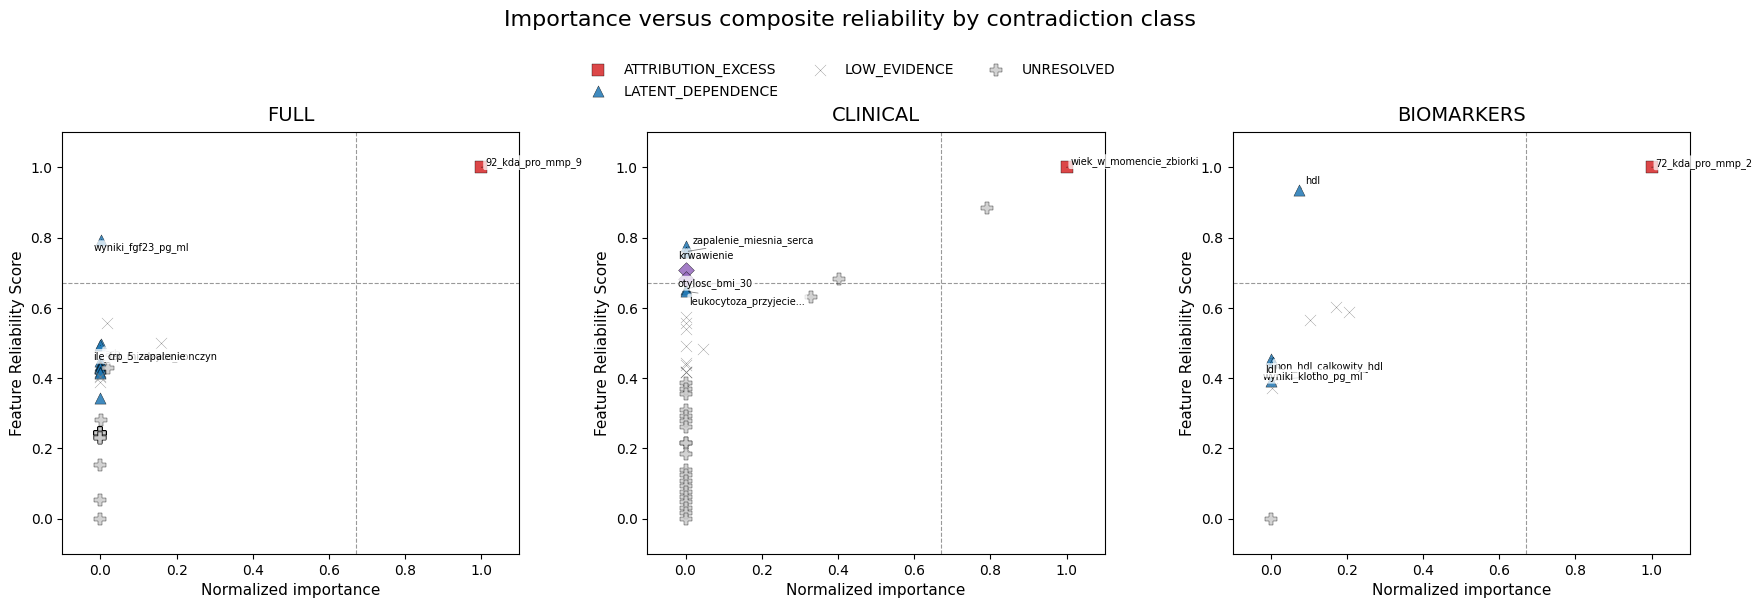

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6.8))
fig.subplots_adjust(top=0.80, bottom=0.18, wspace=0.28)

for ax, variant in zip(axes, VARIANTS):
    sub = feature_table.query("variant == @variant").copy()

    for cls in class_order:
        part = sub[sub["contradiction_class"] == cls]
        if part.empty:
            continue

        ax.scatter(
            part["importance_score"],
            part["FRS"],
            s=65,
            marker=marker_map[cls],
            alpha=0.85,
            label=cls,
            color=class_colors[cls],
            edgecolor="black",
            linewidth=0.3
        )

    annotate_top_points(
        ax=ax,
        data=sub.query("contradiction_class != 'UNRESOLVED'").sort_values("contradiction_abs", ascending=False),
        x_col="importance_score",
        y_col="FRS",
        label_col="feature",
        n=5,
        fontsize=7
    )

    ax.axvline(HIGH_THR, linestyle="--", linewidth=0.8, alpha=0.4, color="black")
    ax.axhline(HIGH_THR, linestyle="--", linewidth=0.8, alpha=0.4, color="black")

    ax.set_title(variant, fontsize=14, pad=8)
    ax.set_xlabel("Normalized importance", fontsize=11)
    ax.set_ylabel("Feature Reliability Score", fontsize=11)
    ax.tick_params(axis="both", labelsize=10)
    ax.margins(x=0.10, y=0.10)

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, fontsize=10, bbox_to_anchor=(0.5, 0.92))
fig.suptitle("Importance versus composite reliability by contradiction class", fontsize=16, y=0.98)
fig.savefig(OUT_DIR / "S16_plot_importance_vs_FRS_by_class.png", dpi=400, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

## Plot 3: contradiction distribution

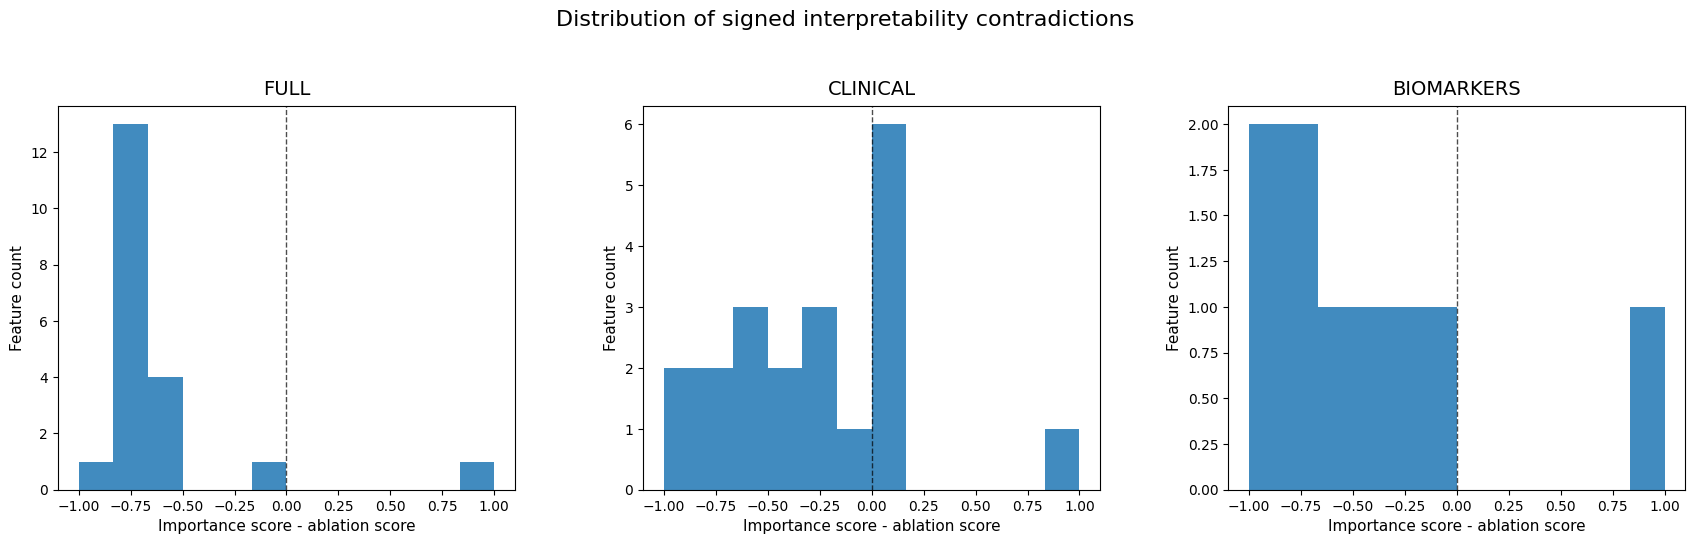

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6.0))
fig.subplots_adjust(top=0.82, bottom=0.18, wspace=0.28)

for ax, variant in zip(axes, VARIANTS):
    sub = feature_table.query("variant == @variant and contradiction_class != 'UNRESOLVED'").copy()

    ax.hist(sub["contradiction_signed"].dropna(), bins=12, alpha=0.85)
    ax.axvline(0, linestyle="--", linewidth=1.0, alpha=0.7, color="black")

    ax.set_title(variant, fontsize=14, pad=8)
    ax.set_xlabel("Importance score - ablation score", fontsize=11)
    ax.set_ylabel("Feature count", fontsize=11)
    ax.tick_params(axis="both", labelsize=10)

fig.suptitle("Distribution of signed interpretability contradictions", fontsize=16, y=0.98)
fig.savefig(OUT_DIR / "S16_plot_contradiction_distribution.png", dpi=400, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

## Plot 4: top contradiction features

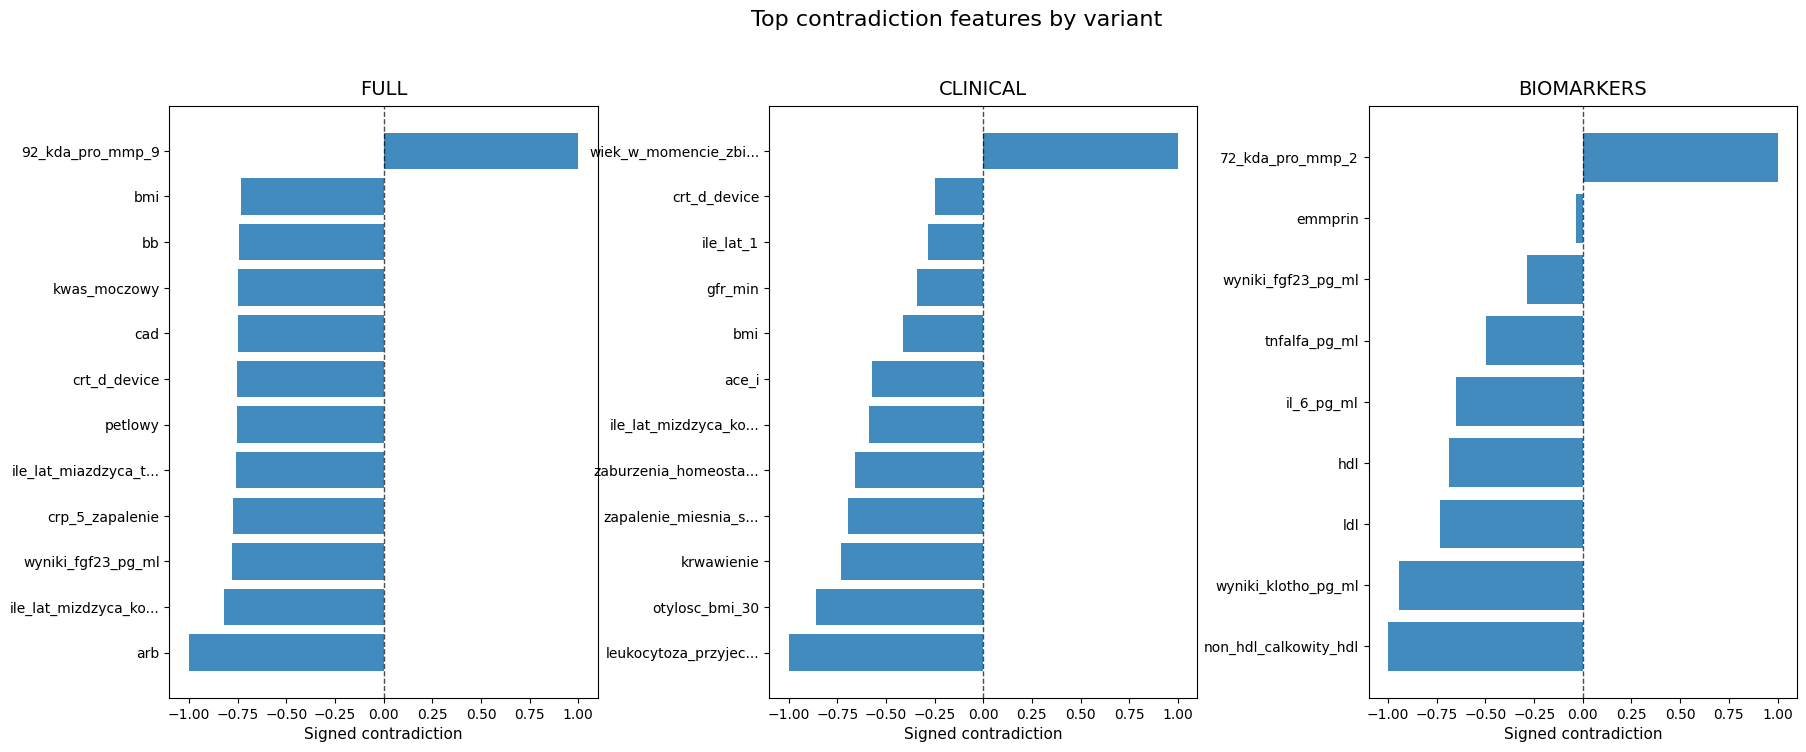

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(21, 8.0))
fig.subplots_adjust(top=0.86, bottom=0.12, wspace=0.40)

for ax, variant in zip(axes, VARIANTS):
    sub = (
        feature_table.query("variant == @variant and contradiction_class != 'UNRESOLVED'")
        .sort_values("contradiction_abs", ascending=False)
        .head(12)
        .copy()
    )

    sub = sub.sort_values("contradiction_signed")

    ax.barh(
        sub["feature"].map(lambda x: shorten_label(x, max_len=22)),
        sub["contradiction_signed"],
        alpha=0.85
    )

    ax.axvline(0, linestyle="--", linewidth=1.0, alpha=0.7, color="black")
    ax.set_title(variant, fontsize=14, pad=8)
    ax.set_xlabel("Signed contradiction", fontsize=11)
    ax.set_ylabel("")
    ax.tick_params(axis="both", labelsize=10)

fig.suptitle("Top contradiction features by variant", fontsize=16, y=0.98)
fig.savefig(OUT_DIR / "S16_plot_top_contradictions_barh.png", dpi=400, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

## Plot 5: contradiction class composition

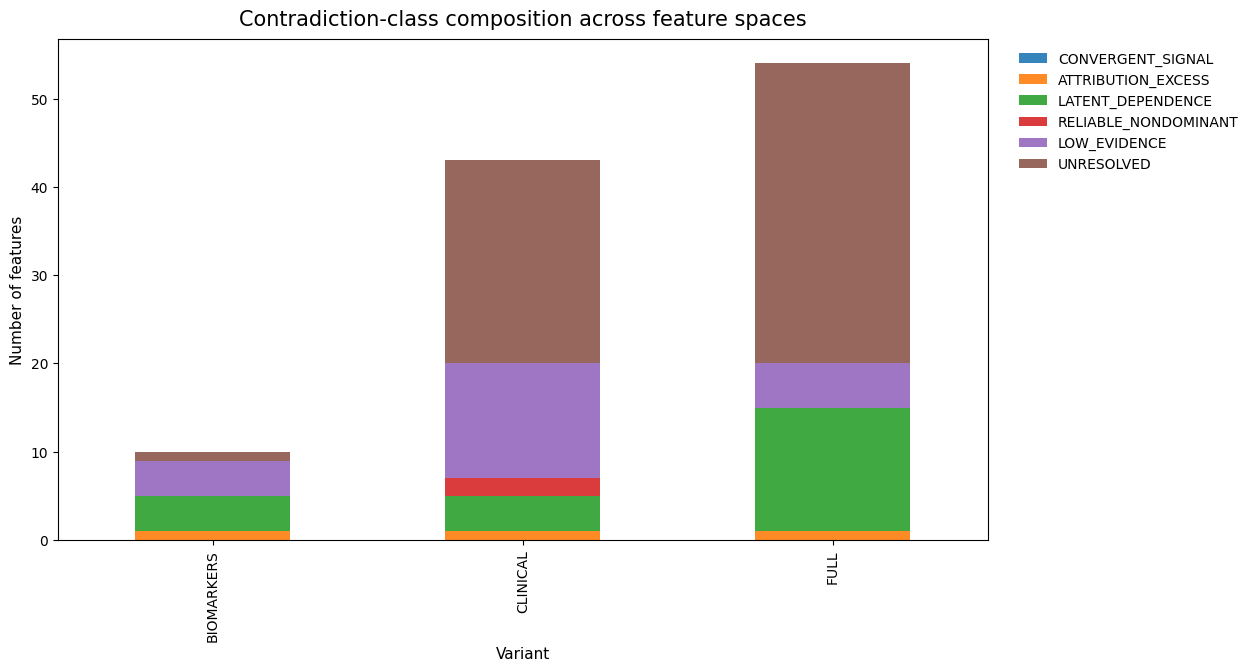

In [25]:
plot_df = contradiction_class_summary.pivot(
    index="variant",
    columns="contradiction_class",
    values="n_features"
).fillna(0)

plot_df = plot_df.reindex(columns=class_order, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6.5))
plot_df.plot(kind="bar", stacked=True, ax=ax, alpha=0.90)

ax.set_title("Contradiction-class composition across feature spaces", fontsize=15, pad=10)
ax.set_xlabel("Variant", fontsize=11)
ax.set_ylabel("Number of features", fontsize=11)
ax.tick_params(axis="both", labelsize=10)
ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

fig.savefig(OUT_DIR / "S16_plot_contradiction_class_composition.png", dpi=400, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

## Display table

In [26]:
display_cols = [
    "variant",
    "feature",
    "importance_mean_nonneg",
    "ablation_delta_auc_mean",
    "importance_score",
    "ablation_score",
    "stability_score",
    "FRS",
    "contradiction_abs",
    "contradiction_signed",
    "feature_class",
    "contradiction_class",
    "complete_case_flag",
]

feature_table.sort_values(["variant", "contradiction_abs"], ascending=[True, False])[display_cols].head(20)

,variant,feature,importance_mean_nonneg,ablation_delta_auc_mean,importance_score,ablation_score,stability_score,FRS,contradiction_abs,contradiction_signed,feature_class,contradiction_class,complete_case_flag
0,BIOMARKERS,72_kda_pro_mmp_2,0.285683,0.137619,1.000000,0.000000,0.803865,1.000000,1.000000,1.000000,SPURIOUS_IMPORTANCE,ATTRIBUTION_EXCESS,1
5,BIOMARKERS,non_hdl_calkowity_hdl,0.000000,0.581905,0.000000,1.000000,0.572409,0.455181,1.000000,-1.000000,HIDDEN_SIGNAL,LATENT_DEPENDENCE,1
7,BIOMARKERS,wyniki_klotho_pg_ml,0.000000,0.556667,0.000000,0.943194,0.516853,0.392645,0.943194,-0.943194,HIDDEN_SIGNAL,LATENT_DEPENDENCE,1
6,BIOMARKERS,ldl,0.001444,0.464762,0.005056,0.736334,0.685322,0.444855,0.731278,-0.731278,HIDDEN_SIGNAL,LATENT_DEPENDENCE,1
1,BIOMARKERS,hdl,0.021032,0.474762,0.073619,0.758842,0.765311,0.936306,0.685223,-0.685223,HIDDEN_SIGNAL,LATENT_DEPENDENCE,1
8,BIOMARKERS,il_6_pg_ml,0.000825,0.429048,0.002889,0.655949,0.628994,0.371348,0.653059,-0.653059,LOW_SIGNAL,LOW_EVIDENCE,1
4,BIOMARKERS,tnfalfa_pg_ml,0.029333,0.403810,0.102678,0.599143,0.816211,0.563966,0.496464,-0.496464,LOW_SIGNAL,LOW_EVIDENCE,1
2,BIOMARKERS,wyniki_fgf23_pg_ml,0.048952,0.340476,0.171352,0.456592,0.868402,0.600903,0.285239,-0.285239,LOW_SIGNAL,LOW_EVIDENCE,1
3,BIOMARKERS,emmprin,0.058841,0.245238,0.205967,0.242229,0.923632,0.587990,0.036262,-0.036262,LOW_SIGNAL,LOW_EVIDENCE,1
9,BIOMARKERS,cholesterol_calkowity_tc,0.000000,NaN,0.000000,NaN,0.461298,0.000000,NaN,NaN,UNRESOLVED,UNRESOLVED,0


## Export full contradiction table

In [27]:
feature_table.to_csv(OUT_DIR / "S16_feature_contradiction_table.csv", index=False)

## Summary

This notebook translated the unified interpretability framework from S15 into a contradiction-focused analysis of feature relevance. The results distinguish between features that are strongly attributed, features that are functionally indispensable, and features that remain reliable despite not being dominant in attribution magnitude.

The outputs generated here are intended to support the Results and Discussion sections of the third manuscript by enabling:
- direct identification of attribution excess,
- detection of latent dependence features,
- cross-variant comparison of contradiction profiles,
- explicit separation between complete-case contradiction analysis and unresolved coverage,
- construction of publication-ready interpretability typologies.

## Saved outputs

In [28]:
print("Saved outputs:")
for path in sorted(OUT_DIR.glob("S16_*")):
    print(path.name)

Saved outputs:
S16_config_snapshot.json
S16_contradiction_class_summary.csv
S16_feature_contradiction_table.csv
S16_plot_contradiction_class_composition.png
S16_plot_contradiction_distribution.png
S16_plot_importance_vs_FRS_by_class.png
S16_plot_importance_vs_ablation_by_class.png
S16_plot_top_contradictions_barh.png
S16_publication_table.csv
S16_top_attribution_excess_features.csv
S16_top_latent_dependence_features.csv
S16_variant_contradiction_summary.csv
S16_variant_profile_with_correlations.csv
